# 11c - Detection Confusion Matrices: L1 / L2 / L1ANDL2 (detection power demo)

2x2 confusion matrices for each detector over the 4 generation variants
(`plain / l1_only / l2_only / dual`):

| detector | positive class (should fire) | negative class (should stay silent) |
|---|---|---|
| **L1** topic greenlist (`z>=4 & p<0.05`) | `l1_only`, `dual` | `plain`, `l2_only` |
| **L2** private KGW (`ownership>0.60 & p<0.05`) | `l2_only`, `dual` | `plain`, `l1_only` |
| **L1^L2** dual-AND (both confirmed) | `dual` | `plain`, `l1_only`, `l2_only` |

Reading the matrices: `l2_only` rows in the L1 matrix and `l1_only` rows in the L2 matrix
are **deliberate cross-checks** - a single-layer watermark must NOT trigger the other
detector. The AND matrix shows the precision/recall trade of requiring both layers.

**Colab flow (v2):**
1. **key** - paste yours into `CONFIG["KEY_OVERRIDE"]`, else reuse the Drive-persisted
   `watermark_key.txt`, else mint once + persist (the old `gen_main.csv` key `1fa8742a...`
   died with its Colab VM, so first run mints a fresh key + corpus)
2. **smoke test** - 1 prompt x 4 variants end-to-end sanity check before spending GPU hours
3. **corpus** - probe any Drive `gen_main.csv` (needs key match); otherwise generate a FRESH
   grid: **100 C4 prompts x 4 variants**, 50-token prompts, <=200 new tokens, id-resumable
   with chunked Drive checkpointing (smoke-test rows count as id 0)
4. **detect** all rows (resumable) -> `eval_results/detection/confusion_*.csv`,
   figures `e3c_*.png`

**Runtime:** smoke ~1 min - fresh corpus ~35-50 min on T4 - detection ~5 min.

In [ ]:
# ---- setup: repo, deps, platform, dirs, imports, config ----
!git clone https://github.com/pravaspaudel/Dual_watermarking_Scheme.git
%cd Dual_watermarking_Scheme
!pip install -q transformers scipy pandas matplotlib accelerate sentencepiece tqdm


import os, math, time, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# imports BEFORE any key handling (minting needs generate_key)
from src.utils.model import load_model
from src.utils.key_manager import generate_key
from src.watermark.dual_layer import DualWaterMarking
from src.detection.topic_detection import prepare, detect_topic_watermark
from src.detection.kgw_detection import detect_private_watermark
from src.metrics.perplexity import split_continuation

if os.path.exists("/kaggle"):
    PLATFORM = "kaggle"                      # Kaggle ships a colab stub - detect via fs
else:
    try:
        from google.colab import drive       # Colab
        drive.mount('/content/drive')
        PLATFORM = "colab"
    except Exception:
        PLATFORM = "local"
print("platform:", PLATFORM)

if PLATFORM == "colab":
    DRIVE = "/content/drive/MyDrive/minor_project"
elif PLATFORM == "kaggle":
    DRIVE = "/kaggle/working/minor_project"
else:
    DRIVE = os.path.abspath("./eval_results")
DETDIR    = f"{DRIVE}/eval_results/detection"
FIGDIR    = f"{DRIVE}/eval_results/figures"
GENDIR    = f"{DRIVE}/eval_results/generation"
for d in (DRIVE, DETDIR, FIGDIR, GENDIR):
    os.makedirs(d, exist_ok=True)

MAIN_CSV   = f"{GENDIR}/gen_main.csv"           # optional pre-existing corpus
CORPUS_CSV = f"{DETDIR}/confusion_corpus.csv"   # fresh corpus (this notebook)
DETECT_CSV = f"{DETDIR}/confusion_detection.csv"
METRICS_CSV= f"{DETDIR}/confusion_metrics.csv"
KEY_FILE   = f"{DRIVE}/watermark_key.txt"       # persists across sessions

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE == "cuda", ("no GPU - Colab: Runtime > Change runtime type > GPU; "
                          "Kaggle: Settings > Accelerator > GPU T4 x2")

CONFIG = {
    # fresh-corpus generation
    "N_PROMPTS"      : 100,     # was 200 -> halved GPU time (~40 min on T4)
    "PROMPT_TOKENS"  : 50,      # truncate C4 prompt to its first 50 tokens
    "MAX_NEW_TOKENS" : 200,
    "DELTA_PUBLIC"   : 2.0,
    "DELTA_PRIVATE"  : 0.7,
    "SEED_BASE"      : 1000,    # per-row seed = SEED_BASE + i
    "CHUNK"          : 10,      # prompts buffered before csv flush (40 rows)
    # detection thresholds (legacy defaults)
    "Z_TH"           : 4.0,
    "P_TH"           : 0.05,
    "OWN_TH"         : 0.60,
    # key probe (only consulted when a pre-existing gen_main.csv is found)
    "KEY_PROBE_N"             : 3,
    "KEY_PROBE_MIN_OWNERSHIP" : 0.70,
    # paste a 64-hex WATERMARK_SECRET_KEY here to force it; "" = auto
    "KEY_OVERRIDE"   : "",
}

VMAP = {"plain_output": "plain", "layer1_only_output": "l1_only",
        "layer2_only_output": "l2_only", "dual_watermarked_output": "dual"}

def merge_and_save(buf, path):
    old = pd.read_csv(path) if os.path.exists(path) else None
    merged = pd.concat([old, pd.DataFrame(buf)]) if old is not None else pd.DataFrame(buf)
    merged.to_csv(path, index=False)

def detect_row(cont):
    """both detectors on one continuation -> flat dict"""
    l1 = detect_topic_watermark(cont, tokenizer, state, VOCAB_SIZE,
                                z_threshold=CONFIG["Z_TH"],
                                p_value_threshold=CONFIG["P_TH"])
    l2 = detect_private_watermark(cont, tokenizer, KEY, VOCAB_SIZE,
                                  green_fraction=0.5, prev_token_size=5,
                                  threshold=CONFIG["OWN_TH"],
                                  p_value_threshold=CONFIG["P_TH"])
    return {"l1_z": l1["z_score"], "l1_topic": l1["topic"],
            "l1_confirmed": bool(l1["confirmed"]),
            "l2_ownership": round(l2["ownership_score"], 4),
            "l2_confirmed": bool(l2["confirmed"]),
            "and_confirmed": bool(l1["confirmed"] and l2["confirmed"])}

def norm_text(prompt, text):
    text = str(text)
    return text if text.startswith(prompt) else prompt + text   # gen_main schema

print("device:", DEVICE, "| gpu:", torch.cuda.get_device_name(0))

In [3]:
# ---- key: override -> Drive-persisted -> mint ONCE and persist ----
# L2 is keyed: generation-time key == detection-time key or ownership ~0.5.
EXPECTED_DEAD_FP = "1fa8742a"   # fingerprint of the lost gen_main.csv key (FYI only)

def valid_key(k):
    return isinstance(k, str) and len(k) == 64 and all(c in "0123456789abcdef" for c in k.lower())

fresh_key = False
if CONFIG["KEY_OVERRIDE"]:
    KEY = CONFIG["KEY_OVERRIDE"].strip().lower()
    assert valid_key(KEY), "KEY_OVERRIDE must be a 64-char hex string"
    open(KEY_FILE, "w").write(KEY)
    key_src = "CONFIG['KEY_OVERRIDE'] -> persisted to Drive"
elif os.path.exists(KEY_FILE):
    KEY = open(KEY_FILE).read().strip()
    key_src = f"reused {KEY_FILE}"
else:
    KEY = generate_key()
    open(KEY_FILE, "w").write(KEY)
    fresh_key = True
    key_src = "minted -> persisted to Drive"

assert valid_key(KEY), f"{KEY_FILE} corrupted - delete it and rerun"
print(f"key fingerprint: {KEY[:8]} | {key_src}")
if KEY[:8] == EXPECTED_DEAD_FP:
    print("[warn] this is the OLD gen_main.csv fingerprint - if that file is probed below it will match; otherwise irrelevant")
if fresh_key:
    for stale in (CORPUS_CSV, DETECT_CSV):      # old-key results are meaningless
        if os.path.exists(stale):
            os.remove(stale)
            print("removed stale old-key file:", os.path.basename(stale))

key fingerprint: 22e8014d | minted -> persisted to Drive


In [4]:
# ---- model + shared detection state + watermark engine ----
model, tokenizer, VOCAB_SIZE = load_model("facebook/opt-2.7b")
model.half().to(DEVICE).eval()                  # repo convention: fp16 on GPU

state = prepare(model, tokenizer, greenlist_dir="data/greenlist", split="all")
print("topics:", state["topics"])
print("gamma per topic:", {t: round(len(state["green_sets"][t]) / VOCAB_SIZE, 5)
                           for t in state["topics"]})

wm = DualWaterMarking(
    model, tokenizer, key=KEY,
    greenlist_dir="data/greenlist", split="all",
    delta_public=CONFIG["DELTA_PUBLIC"], delta_private=CONFIG["DELTA_PRIVATE"],
    max_new_tokens=CONFIG["MAX_NEW_TOKENS"],
    normed_embeddings=state["normed_embeddings"],   # reuse fp32 routing geometry
    topic_matrix=state["topic_matrix"],
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

model and tokenizer of facebook/opt-2.7b loaded with vocab_size 50265


model.safetensors:   0%|          | 0.00/5.30G [00:00<?, ?B/s]

topics: ['entertainment', 'finance', 'history', 'medicine', 'politics', 'science', 'sports', 'technology']
gamma per topic: {'entertainment': 0.08443, 'finance': 0.08427, 'history': 0.11545, 'medicine': 0.08415, 'politics': 0.15321, 'science': 0.1212, 'sports': 0.13349, 'technology': 0.22361}


In [5]:
# ---- SMOKE TEST: 1 prompt x 4 variants end-to-end before spending GPU hours ----
# uses prompt id 0 of the exact sample the corpus cell will use, so on PASS the 4
# generated rows are checkpointed as id 0 and never regenerated.
c4 = pd.read_csv("data/extracted/c4_samples.csv")
p0 = c4.sample(n=CONFIG["N_PROMPTS"], random_state=0)["prompt_text"].tolist()[0]
SMOKE_PROMPT = tokenizer.decode(
    tokenizer.encode(p0, add_special_tokens=False)[:CONFIG["PROMPT_TOKENS"]])

existing_ids = set()
if os.path.exists(CORPUS_CSV):
    existing_ids = set(pd.read_csv(CORPUS_CSV)["id"].tolist())

if 0 in existing_ids:
    smoke_rows = pd.read_csv(CORPUS_CSV)
    smoke_rows = smoke_rows[smoke_rows["id"] == 0]
    print("smoke rows already in corpus - reloading them")
else:
    torch.manual_seed(CONFIG["SEED_BASE"])               # same seed corpus loop would use
    outs = wm.watermark([SMOKE_PROMPT], include_single_layers=True).iloc[0]
    smoke_rows = pd.DataFrame([
        {"id": 0, "prompt_text": SMOKE_PROMPT, "topic": outs["topic"],
         "variant": v, "seed": CONFIG["SEED_BASE"],
         "text": norm_text(SMOKE_PROMPT, outs[raw])}
        for raw, v in VMAP.items()
    ])
    merge_and_save(smoke_rows.to_dict("records"), CORPUS_CSV)
    print("(id-0 rows checkpointed to corpus - the main loop will skip them)")

EXPECT = {                       # variant -> (L1 should fire, L2 should fire)
    "plain":   (False, False),
    "l1_only": (True,  False),
    "l2_only": (False, True),
    "dual":    (True,  True),
}
results, n_pass = {}, 0
print(f"\nprompt: {SMOKE_PROMPT[:90]}...\n")
for _, r in smoke_rows.iterrows():
    cont = split_continuation(r["prompt_text"], r["text"])
    det = detect_row(cont)
    results[r["variant"]] = det
    e1, e2 = EXPECT[r["variant"]]
    ok = (det["l1_confirmed"] == e1) and (det["l2_confirmed"] == e2)
    n_pass += ok
    flag = "PASS" if ok else "FAIL"
    print(f"[{flag}] {r['variant']:8s} | L1 z={det['l1_z']:7.2f} fires={det['l1_confirmed']!s:5s} "
          f"(want {e1!s:5s}) | L2 own={det['l2_ownership']:.3f} fires={det['l2_confirmed']!s:5s} "
          f"(want {e2!s:5s})")

print(f"\nsmoke test: {n_pass}/4 expectations met")
if n_pass == 4:
    print("ALL GOOD - continue to corpus generation")
else:
    print("[warn] unexpected pattern - inspect above before running the full corpus")

(id-0 rows checkpointed to corpus - the main loop will skip them)

prompt: NATICK, Mass. -- Before a series of late-winter nor'easters covered New England with heavy...

[PASS] plain    | L1 z=  -2.16 fires=False (want False) | L2 own=0.503 fires=False (want False)
[FAIL] l1_only  | L1 z=  -3.12 fires=False (want True ) | L2 own=0.467 fires=False (want False)
[PASS] l2_only  | L1 z=  -2.23 fires=False (want False) | L2 own=0.661 fires=True  (want True )
[PASS] dual     | L1 z=   7.34 fires=True  (want True ) | L2 own=0.641 fires=True  (want True )

smoke test: 3/4 expectations met
[warn] unexpected pattern - inspect above before running the full corpus


In [6]:
# ---- acquire evaluation corpus: probe Drive copy, else generate fresh (resumable) ----
corpus = None
if os.path.exists(MAIN_CSV):
    df_main = pd.read_csv(MAIN_CSV)
    dual = df_main[df_main["variant"] == "dual"].head(CONFIG["KEY_PROBE_N"])
    owns = [detect_private_watermark(split_continuation(r["prompt_text"], r["text"]),
                                     tokenizer, KEY, VOCAB_SIZE, green_fraction=0.5,
                                     prev_token_size=5, threshold=CONFIG["OWN_TH"],
                                     p_value_threshold=CONFIG["P_TH"])["ownership_score"]
            for _, r in dual.iterrows()]
    mo = float(np.mean(owns)) if owns else 0.0
    ok = mo >= CONFIG["KEY_PROBE_MIN_OWNERSHIP"]
    print(f"key probe on {MAIN_CSV}: mean ownership={mo:.3f} -> {'MATCH' if ok else 'MISMATCH'}")
    if ok:
        corpus = df_main

if corpus is None:
    print(f"=> generating fresh corpus: {CONFIG['N_PROMPTS']} prompts x 4 variants, "
          f"{CONFIG['PROMPT_TOKENS']}-token prompts, <={CONFIG['MAX_NEW_TOKENS']} new tokens")
    prompts_raw = c4.sample(n=CONFIG["N_PROMPTS"], random_state=0)["prompt_text"].tolist()
    prompts = [tokenizer.decode(tokenizer.encode(p, add_special_tokens=False)
                                [:CONFIG["PROMPT_TOKENS"]]) for p in prompts_raw]

    done = set()
    if os.path.exists(CORPUS_CSV):
        done = set(pd.read_csv(CORPUS_CSV)["id"].tolist())
        print(f"resume: {len(done)} prompts already generated")

    buf, t0 = [], time.time()
    for i, prompt in enumerate(tqdm(prompts, desc="generate")):
        if i in done:
            continue
        torch.manual_seed(CONFIG["SEED_BASE"] + i)
        outs = wm.watermark([prompt], include_single_layers=True).iloc[0]
        for raw, variant in VMAP.items():
            buf.append({"id": i, "prompt_text": prompt, "topic": outs["topic"],
                        "variant": variant, "seed": CONFIG["SEED_BASE"] + i,
                        "text": norm_text(prompt, outs[raw])})
        if len(buf) >= 4 * CONFIG["CHUNK"]:
            merge_and_save(buf, CORPUS_CSV); buf = []
    if buf:
        merge_and_save(buf, CORPUS_CSV)
    corpus = pd.read_csv(CORPUS_CSV)
    print(f"generated {len(corpus)} rows in {(time.time()-t0)/60:.1f} min")

assert not corpus["text"].isna().any(), "empty generations in corpus"
print("\ncorpus:", len(corpus), "rows | variants:",
      corpus["variant"].value_counts().to_dict())

=> generating fresh corpus: 100 prompts x 4 variants, 50-token prompts, <=200 new tokens
resume: 1 prompts already generated


generate:   0%|          | 0/100 [00:00<?, ?it/s]

generated 400 rows in 39.7 min

corpus: 400 rows | variants: {'plain': 100, 'l1_only': 100, 'l2_only': 100, 'dual': 100}


In [7]:
# ---- detection over the whole corpus (continuation-only, resumable) ----
done = set()
if os.path.exists(DETECT_CSV):
    d = pd.read_csv(DETECT_CSV)
    done = set(zip(d["id"], d["variant"]))
    print(f"resume: {len(done)} rows already scored")

buf, t0 = [], time.time()
for r in tqdm(corpus.to_dict("records"), desc="detect", total=len(corpus)):
    if (r["id"], r["variant"]) in done:
        continue
    cont = split_continuation(r["prompt_text"], r["text"])
    res = detect_row(cont)
    buf.append({"id": r["id"], "variant": r["variant"], "topic": r["topic"], **res})
    if len(buf) >= 25:
        merge_and_save(buf, DETECT_CSV); buf = []
if buf:
    merge_and_save(buf, DETECT_CSV)

det = pd.read_csv(DETECT_CSV)
print(f"detection: {len(det)} rows in {(time.time()-t0)/60:.1f} min")
print("\nconfirmed-rate per variant (sanity):")
print(det.groupby("variant")[["l1_confirmed", "l2_confirmed", "and_confirmed"]]
         .mean().round(3).to_string())

detect:   0%|          | 0/400 [00:00<?, ?it/s]

detection: 400 rows in 4.9 min

confirmed-rate per variant (sanity):
         l1_confirmed  l2_confirmed  and_confirmed
variant                                           
dual             0.83          0.56           0.53
l1_only          0.82          0.02           0.01
l2_only          0.00          0.50           0.00
plain            0.00          0.01           0.00


In [8]:
# ---- confusion matrices + metrics per detector ----
def confusion(det, detector_col, positives):
    pred = det[detector_col].astype(bool)
    true_pos = det["variant"].isin(positives)
    tp = int((pred & true_pos).sum());  fn = int((~pred & true_pos).sum())
    tn = int((~pred & ~true_pos).sum()); fp = int((pred & ~true_pos).sum())
    tpr = tp / (tp + fn) if tp + fn else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0
    prec = tp / (tp + fp) if tp + fp else 0.0
    acc  = (tp + tn) / len(det)
    f1   = 2 * prec * tpr / (prec + tpr) if prec + tpr else 0.0
    return {"detector": detector_col.replace("_confirmed", ""),
            "positives": "+".join(positives),
            "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "TPR": round(tpr, 3), "FPR": round(fpr, 3),
            "precision": round(prec, 3), "accuracy": round(acc, 3),
            "f1": round(f1, 3)}

SPEC = [
    ("l1_confirmed",  ["l1_only", "dual"]),
    ("l2_confirmed",  ["l2_only", "dual"]),
    ("and_confirmed", ["dual"]),
]
metrics = pd.DataFrame([confusion(det, c, pos) for c, pos in SPEC])
metrics.to_csv(METRICS_CSV, index=False)
print(metrics.to_string(index=False))

print("\nper-variant breakdown (what fires on what):")
print(det.groupby("variant")[["l1_confirmed", "l2_confirmed", "and_confirmed"]]
         .mean().round(3).to_string())

detector    positives  TP  FP  TN  FN   TPR   FPR  precision  accuracy    f1
      l1 l1_only+dual 165   0 200  35 0.825 0.000      1.000     0.912 0.904
      l2 l2_only+dual 106   3 197  94 0.530 0.015      0.972     0.757 0.686
     and         dual  53   1 299  47 0.530 0.003      0.981     0.880 0.688

per-variant breakdown (what fires on what):
         l1_confirmed  l2_confirmed  and_confirmed
variant                                           
dual             0.83          0.56           0.53
l1_only          0.82          0.02           0.01
l2_only          0.00          0.50           0.00
plain            0.00          0.01           0.00


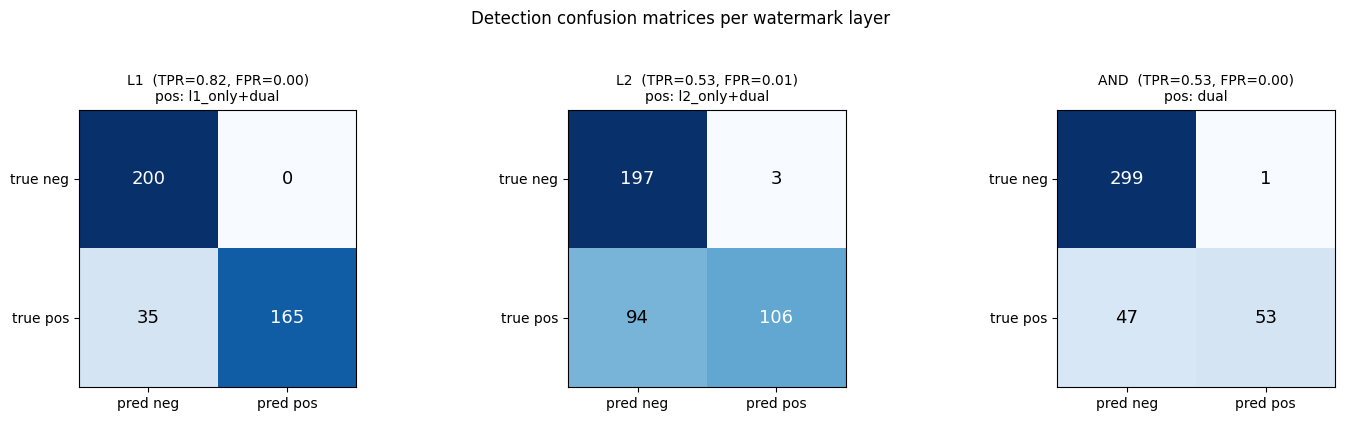

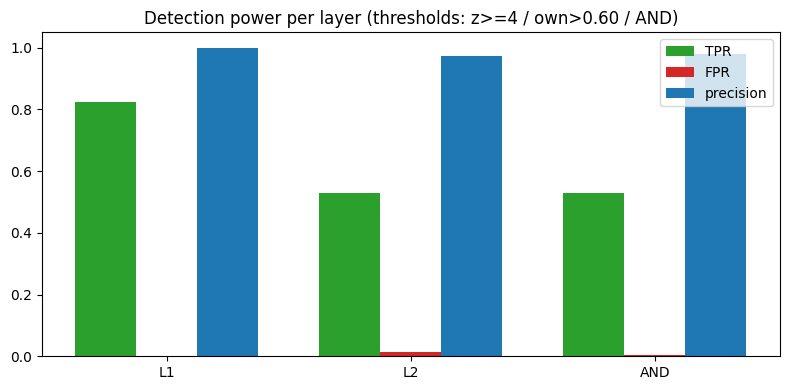

saved: /kaggle/working/minor_project/eval_results/detection/confusion_metrics.csv
saved: /kaggle/working/minor_project/eval_results/figures/e3c_confusion_matrices.png , e3c_detection_power_bars.png


In [9]:
# ---- figures: 3 heatmaps + grouped metric bars ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, metrics.iterrows()):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(int(v)), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=13)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred neg", "pred pos"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true neg", "true pos"])
    ax.set_title(f"{row['detector'].upper()}  (TPR={row['TPR']:.2f}, FPR={row['FPR']:.2f})\n"
                 f"pos: {row['positives']}", fontsize=10)
plt.suptitle("Detection confusion matrices per watermark layer", y=1.04)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/e3c_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metrics)); w = 0.25
for k, (col, c) in enumerate([("TPR", "#2ca02c"), ("FPR", "#d62728"),
                              ("precision", "#1f77b4")]):
    ax.bar(x + (k - 1) * w, metrics[col], w, label=col, color=c)
ax.set_xticks(x); ax.set_xticklabels(metrics["detector"].str.upper())
ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("Detection power per layer (thresholds: z>=4 / own>0.60 / AND)")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/e3c_detection_power_bars.png", dpi=300)
plt.show()
print("saved:", METRICS_CSV)
print("saved:", f"{FIGDIR}/e3c_confusion_matrices.png , e3c_detection_power_bars.png")

In [10]:

m = {row["detector"]: row for _, row in metrics.iterrows()}
print("checks:")
print(f"  L1 FPR (plain+l2_only stay silent)      : {m['l1']['FPR']:.3f}  (want ~0)")
print(f"  L2 FPR (plain+l1_only stay silent)      : {m['l2']['FPR']:.3f}  (want ~0)")
print(f"  AND FPR (only dual should fire)         : {m['and']['FPR']:.3f}  (want ~0)")
print(f"  L1 TPR on l1_only+dual                  : {m['l1']['TPR']:.3f}")
print(f"  L2 TPR on l2_only+dual                  : {m['l2']['TPR']:.3f}")
print(f"  AND TPR on dual (cost of requiring both): {m['and']['TPR']:.3f}")
print('''
expected story: both layers detect their own watermarks near-perfectly at these
thresholds, cross-fire ~0, and the AND rule keeps FPR ~0 while TPR drops to the
min(l1, l2) rate on dual rows - the security/robustness trade-off to discuss.''')

checks:
  L1 FPR (plain+l2_only stay silent)      : 0.000  (want ~0)
  L2 FPR (plain+l1_only stay silent)      : 0.015  (want ~0)
  AND FPR (only dual should fire)         : 0.003  (want ~0)
  L1 TPR on l1_only+dual                  : 0.825
  L2 TPR on l2_only+dual                  : 0.530
  AND TPR on dual (cost of requiring both): 0.530

expected story: both layers detect their own watermarks near-perfectly at these
thresholds, cross-fire ~0, and the AND rule keeps FPR ~0 while TPR drops to the
min(l1, l2) rate on dual rows - the security/robustness trade-off to discuss.


In [11]:
# ---- upload/backup 11c outputs to Google Drive ----
# consolidates stray repo-cwd outputs into {DRIVE}/eval_results and leaves a
# timestamped zip snapshot under eval_results/backups/ (Drive on Colab)
import glob, shutil, datetime

BACKUP_ROOT = f"{DRIVE}/eval_results"
for sub in ("detection", "figures", "backups"):
    os.makedirs(f"{BACKUP_ROOT}/{sub}", exist_ok=True)

copied = []
for src_root in ["eval_results", BACKUP_ROOT]:      # repo-cwd strays first
    if not os.path.isdir(src_root):
        continue
    for pat in ["detection/confusion_*.csv", "figures/e3c_*.png"]:
        for f in glob.glob(os.path.join(src_root, pat)):
            dst = os.path.join(BACKUP_ROOT, os.path.relpath(f, src_root))
            if os.path.abspath(f) == os.path.abspath(dst):
                continue                            # already lives in Drive
            shutil.copy2(f, dst)
            copied.append(dst)

print("copied:" if copied else "nothing new - 11c outputs already live in Drive")
for c in copied:
    print(" ", c)

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
zip_base = shutil.make_archive(f"11c_{stamp}", "zip",
                               root_dir=os.path.dirname(BACKUP_ROOT),
                               base_dir="eval_results")
if PLATFORM == "colab":
    final_zip = shutil.move(zip_base, f"{BACKUP_ROOT}/backups/11c_results_{stamp}.zip")
    print(f"snapshot: {final_zip} ({os.path.getsize(final_zip)/1e6:.1f} MB)")
else:
    print(f"snapshot (local): {zip_base}")

nothing new - 11c outputs already live in Drive
snapshot (local): /content/Dual_watermarking_Scheme/11c_20260825_1428.zip
